>Lisbeth Martinez

>Project Title: Identifying Streaming Behavior Across Attributes of Region and Genre

>Description: Understanding patterns in music streaming platforms allows labels and artists to visualize how their music is most listened to. Clustering streams by genre and sorting by region enables companies to establish a strategic domain impact. 

# Contents:
1. [Data loading and Overview](#Data-Loading-and-Overview)
2. [Exploratory Data Analysis with Visualizations](#Exploratory-Data-Analysis-with-Visualizations)
3. [Data Transformation and Applying the Mining Technique](#Data-Transformation-and-Applying-the-Mining-Technique)
4. [M2 Preliminary Findings with Interpretation](#M2-Preliminary-Findings-with-Interpretation)
5. [Geographical Context](#Geographical-Context)
6. [M3 Findings with Interpretation](M3-Findings-with-Interpretation)

# Analytical Choices and Updates from Module 2
- K-Means clustering: selected to identify listener segments from continuous engagement metrics.
- Apriori association rules were used to discover co-occurrence relationships among country, genre, and platform behavior.
- Decision tree classification was added for M3 to explain the discovered clusters through interpretable behavioral rules.
- PCA visualization was added to validate cluster separation in reduced dimensions.

These methods were selected because clustering identifies segments, association rules explain co-occurrence, and decision trees explain segment boundaries.

Furthermore, based on prior feedback, M3 builds off of M2 by moving from manual containers to quantile bins, to address the "Low" section capturing little data as the feedback states. Other feedback included contradictions over minimum lift threshold, which was a result of file loss/recovery and a lack of noting unsaved changes. The minimum threshold / minimum confidence has since been rewritten as 0.6 to accurately filter confidence.

# Data Loading and Overview

In [153]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

from mlxtend.frequent_patterns import apriori, association_rules

sns.set(style="whitegrid")

>The section below is an overview of the 5000 rows and 12 columns, including: the head displaying the first five rows, information about the data type, and a summary of statistics. Preprocessing checks for missing values, prints them, and also checks for duplicate rows.

Dataset Shape: (5000, 12)


,User_ID,Age,Country,Streaming Platform,Top Genre,Minutes Streamed Per Day,Number of Songs Liked,Most Played Artist,Subscription Type,Listening Time (Morning/Afternoon/Night),Discover Weekly Engagement (%),Repeat Song Rate (%)
0,U1000,34,Japan,Tidal,Reggae,295,138,Adele,Free,Afternoon,47.42,16.74
1,U1001,24,Germany,Deezer,Country,86,388,Ed Sheeran,Premium,Night,12.06,69.25
2,U1002,49,Germany,Deezer,Pop,363,368,Post Malone,Premium,Afternoon,47.19,67.38
3,U1003,55,Australia,YouTube,Reggae,348,349,Dua Lipa,Premium,Morning,31.27,76.51
4,U1004,13,Germany,Amazon Music,Reggae,30,328,Adele,Free,Night,30.68,43.41


<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 12 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   User_ID                                   5000 non-null   str    
 1   Age                                       5000 non-null   int64  
 2   Country                                   5000 non-null   str    
 3   Streaming Platform                        5000 non-null   str    
 4   Top Genre                                 5000 non-null   str    
 5   Minutes Streamed Per Day                  5000 non-null   int64  
 6   Number of Songs Liked                     5000 non-null   int64  
 7   Most Played Artist                        5000 non-null   str    
 8   Subscription Type                         5000 non-null   str    
 9   Listening Time (Morning/Afternoon/Night)  5000 non-null   str    
 10  Discover Weekly Engagement (%)            5000 

,Age,Minutes Streamed Per Day,Number of Songs Liked,Discover Weekly Engagement (%),Repeat Song Rate (%)
count,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,36.664000,309.237200,253.51720,50.296464,42.391060
std,13.763844,172.029822,146.36928,23.171936,21.444121
min,13.000000,10.000000,1.00000,10.020000,5.000000
25%,25.000000,161.000000,126.00000,30.147500,24.195000
50%,37.000000,316.000000,254.00000,50.420000,41.960000
75%,49.000000,457.250000,382.00000,70.337500,60.740000
max,60.000000,600.000000,500.00000,89.990000,79.990000


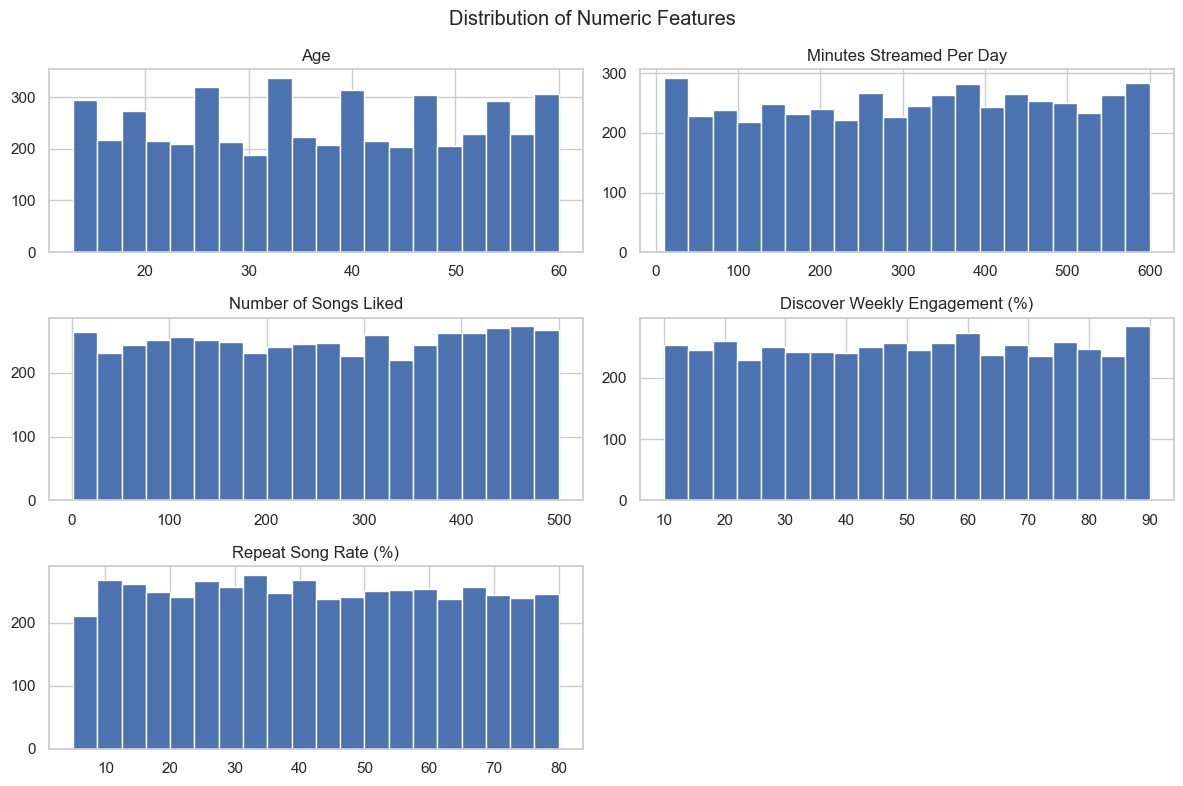

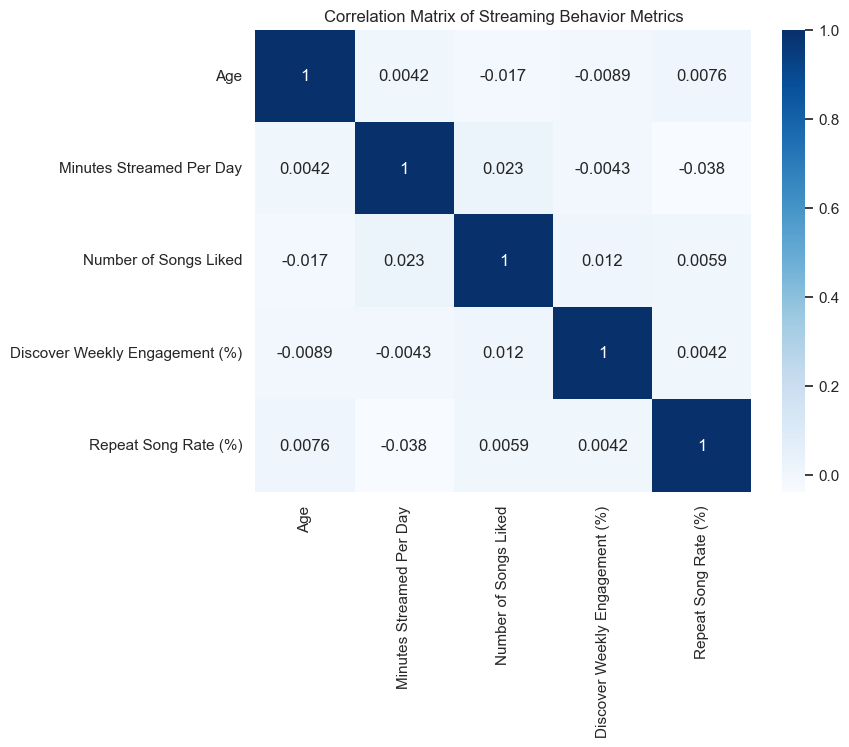


Missing values per column:
User_ID                                     0
Age                                         0
Country                                     0
Streaming Platform                          0
Top Genre                                   0
Minutes Streamed Per Day                    0
Number of Songs Liked                       0
Most Played Artist                          0
Subscription Type                           0
Listening Time (Morning/Afternoon/Night)    0
Discover Weekly Engagement (%)              0
Repeat Song Rate (%)                        0
dtype: int64

Number of duplicate rows: 0


In [154]:
df = pd.read_csv("Global_Music_Streaming_Listener_Preferences (1).csv")

print(f"Dataset Shape: {df.shape}")
#First five rows
display(df.head())

#Type of data
df.info()

#Summary statistics
display(df.describe())
numeric_cols = [
    "Age",
    "Minutes Streamed Per Day",
    "Number of Songs Liked",
    "Discover Weekly Engagement (%)",
    "Repeat Song Rate (%)"
]

df[numeric_cols].hist(figsize=(12,8), bins=20)
plt.suptitle("Distribution of Numeric Features")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,6))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap="Blues")
plt.title("Correlation Matrix of Streaming Behavior Metrics")
plt.show()

print("\nMissing values per column:")
print(df.isnull().sum())

print(f"\nNumber of duplicate rows: {df.duplicated().sum()}")

# Exploratory Data Analysis with Visualizations

>Shows the most frequent data from each column to understand any skews; pre-processing excludes USER ID

In [155]:
df = pd.read_csv("Global_Music_Streaming_Listener_Preferences (1).csv")

most_frequent = df.drop(columns=['User_ID']).mode().iloc[0]
print(most_frequent)

Age                                                 32.0
Country                                        Australia
Streaming Platform                          Amazon Music
Top Genre                                           Jazz
Minutes Streamed Per Day                           152.0
Number of Songs Liked                              320.0
Most Played Artist                             Bad Bunny
Subscription Type                                Premium
Listening Time (Morning/Afternoon/Night)           Night
Discover Weekly Engagement (%)                     76.66
Repeat Song Rate (%)                               16.59
Name: 0, dtype: object


>Genre Popularity by Country shows specific numerics that the bar chart would not for a more direct visualization of how many users have been recording listening to each genre.
>Looking through a category, such as Classical, it is easy to see Brazil and Canada are outliers, with 37 listeners while the other nations hold 45-55.

In [156]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Global_Music_Streaming_Listener_Preferences (1).csv")
genre_country_df = df[["Country", "Top Genre"]]
genre_counts = genre_country_df.groupby(["Country", "Top Genre"]).size().reset_index(name="Count")
genre_pivot = genre_counts.pivot(index="Country", columns="Top Genre", values="Count").fillna(0)

genre_pivot



Top Genre,Classical,Country,EDM,Hip-Hop,Jazz,Metal,Pop,R&B,Reggae,Rock
Country,,,,,,,,,,
Australia,47,49,53,55,60,43,61,48,55,55
Brazil,59,53,48,39,45,44,56,57,46,61
Canada,37,51,59,51,57,38,56,54,55,49
France,42,47,50,52,59,51,35,51,55,51
Germany,45,45,71,44,44,56,37,50,37,42
India,55,49,42,54,52,45,40,45,62,46
Japan,45,55,48,48,57,51,55,41,49,42
South Korea,48,47,56,61,51,52,34,52,51,64
UK,49,42,42,47,56,58,45,59,63,55


>This boxplot is based off of the previous table as a way to identify significant outliers. For example, seeing a dot at 59, I can then cross-reference the table to identify which country holds that outlier.

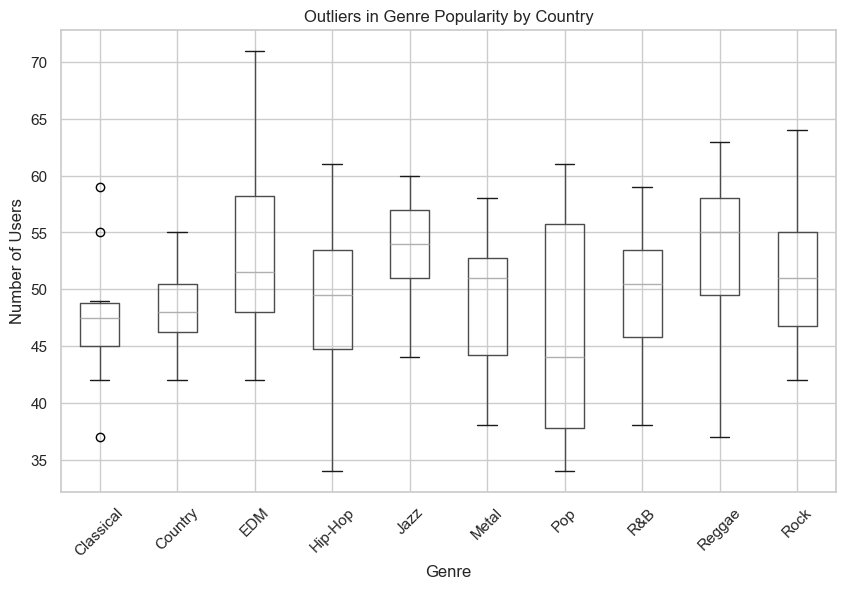

Top Genre  Classical  Country  EDM  Hip-Hop  Jazz  Metal  Pop  R&B  Reggae  \
Country                                                                      
Brazil          59.0      NaN  NaN      NaN   NaN    NaN  NaN  NaN     NaN   
Canada          37.0      NaN  NaN      NaN   NaN    NaN  NaN  NaN     NaN   
India           55.0      NaN  NaN      NaN   NaN    NaN  NaN  NaN     NaN   

Top Genre  Rock  
Country          
Brazil      NaN  
Canada      NaN  
India       NaN  


In [157]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Global_Music_Streaming_Listener_Preferences (1).csv")
plt.figure(figsize=(10,6))
genre_pivot.boxplot()

plt.title("Outliers in Genre Popularity by Country")
plt.xlabel("Genre")
plt.ylabel("Number of Users")
plt.xticks(rotation=45)

plt.show()
Q1 = genre_pivot.quantile(0.25)
Q3 = genre_pivot.quantile(0.75)
IQR = Q3 - Q1

outliers = genre_pivot[(genre_pivot < (Q1 - 1.5 * IQR)) | (genre_pivot > (Q3 + 1.5 * IQR))]

print(outliers.dropna(how="all"))

>Bar Chart shows a better visualization of what stands out.

>EDM is outstandingly popular in Germany in comparison to the other countries listed. South Korea stands out in Rock and Hip-Hop streams.

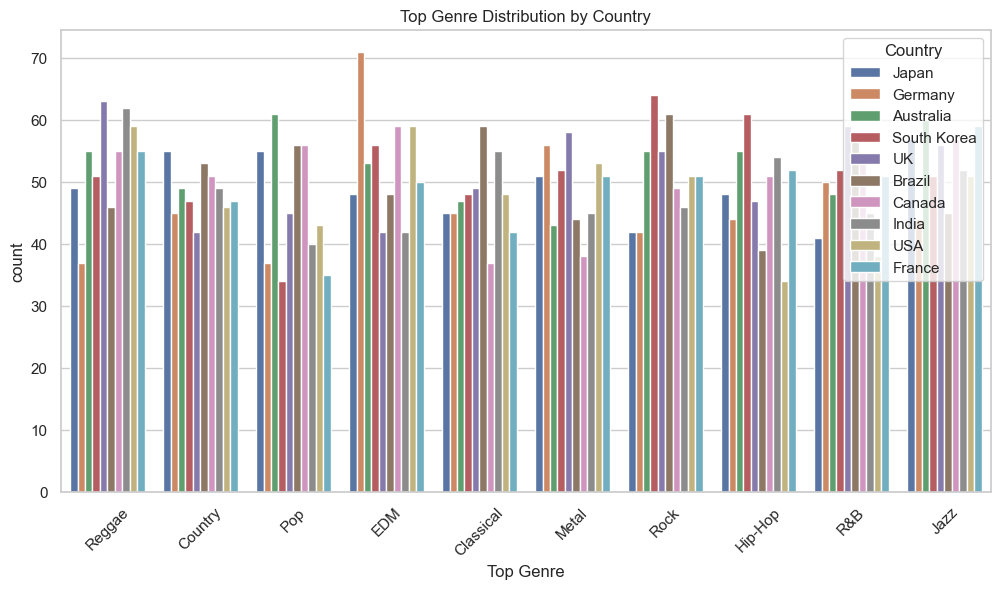

In [158]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.countplot(data=df, x="Top Genre", hue="Country")

plt.title("Top Genre Distribution by Country")
plt.xticks(rotation=45)

plt.show()


>Top Genre distribution by Age

>Hue shift accounts for ages between the legend's marked colors. This data portrays younger groups listening to Reggae and EDM more than older groups. Those around the age of 24 or 56 tend to listen to Rock at an equal rate, while Metal is majorly listened to by those around the age of 32. The age groups in 40 and older tend to hold the highest listening rate of Country, with outliers existing between 32 and 40.

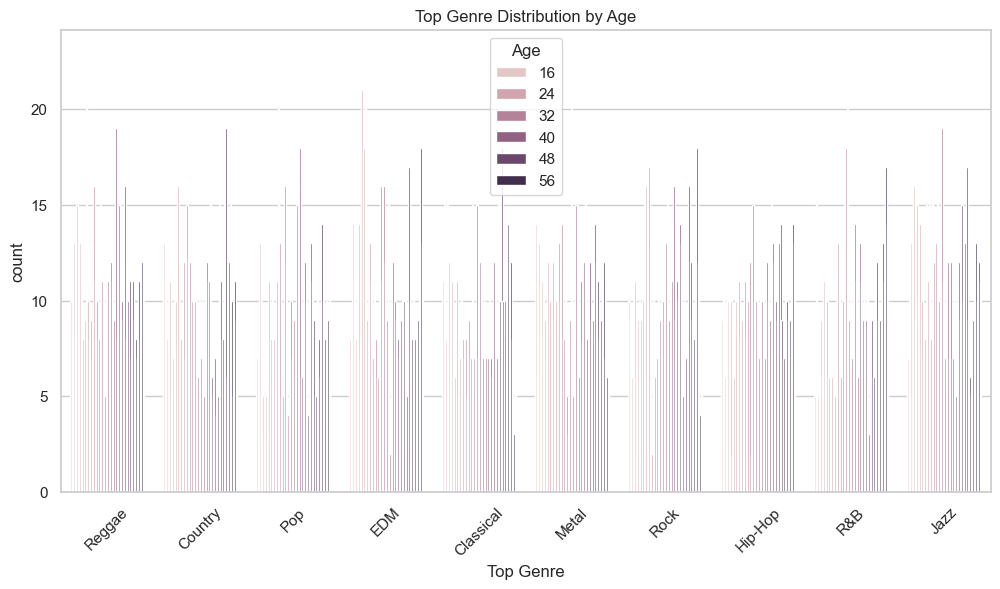

In [159]:
plt.figure(figsize=(12,6))

sns.countplot(data=df, x="Top Genre", hue="Age")

plt.title("Top Genre Distribution by Age")
plt.xticks(rotation=45)

plt.show()


>This line chart prioritizes the six most popular genres for easier visualization of which age holds a spike in the popularity of a genre.
>Preprocesses data by lessening the amount of genres looked at.
>Most Jazz listeners are in their late 20s and early 30s, matching the bar chart. However, one noticebale difference the line chart makes easier to see is that those around their mid 20s tend to listen to Rock slightly more frequently than those in their mid 50s.

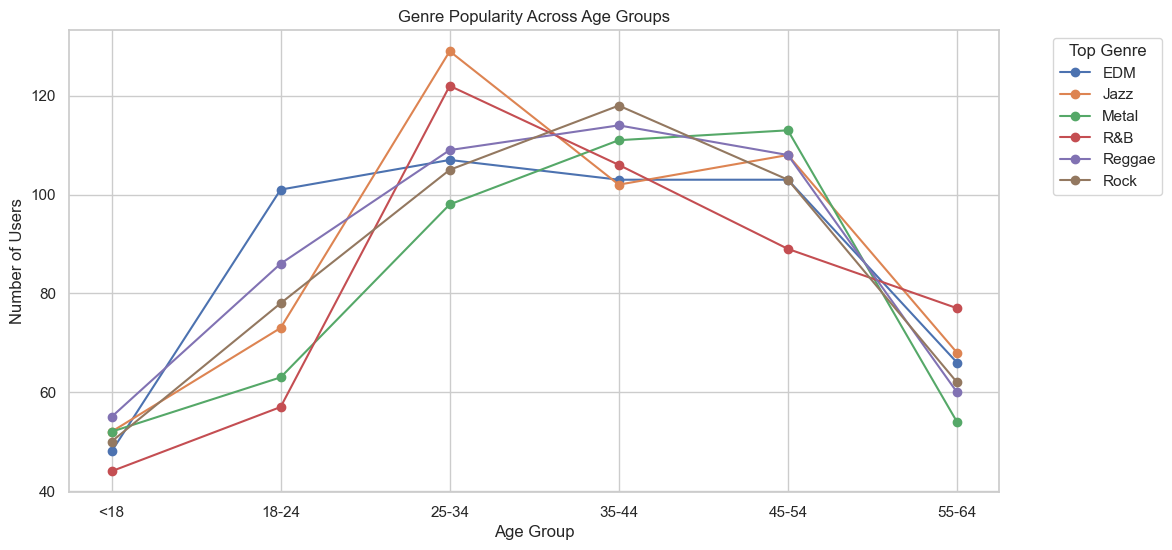

In [160]:
import pandas as pd
import matplotlib.pyplot as plt


# Load data
df = pd.read_csv("Global_Music_Streaming_Listener_Preferences (1).csv")

top_genres = df["Top Genre"].value_counts().head(6).index
df = df[df["Top Genre"].isin(top_genres)]

# Bin ages into groups
bins = [0, 17, 24, 34, 44, 54, 64, 100]
labels = ["<18","18-24","25-34","35-44","45-54","55-64","65+"]
df["Age Group"] = pd.cut(df["Age"], bins=bins, labels=labels)

# Count genre popularity by age group
genre_age = df.groupby(["Age Group", "Top Genre"]).size().reset_index(name="Count")

# Pivot for line chart
genre_age_pivot = genre_age.pivot(index="Age Group", columns="Top Genre", values="Count").fillna(0)

# Plot
plt.figure(figsize=(12,6))
for genre in genre_age_pivot.columns:
    plt.plot(genre_age_pivot.index, genre_age_pivot[genre], marker='o', label=genre)

plt.title("Genre Popularity Across Age Groups")
plt.xlabel("Age Group")
plt.ylabel("Number of Users")
plt.legend(title="Top Genre", bbox_to_anchor=(1.05,1), loc='upper left')
plt.grid(True)
plt.show()

# Data Transformation and Applying the Mining Technique

>Preprocessing was used to remove unnecessary data, such as USER ID.

>Transformation was accomplished by sorting numerical columns, such as stream and like counts per user, into bins.

Cluster Interpretation

Cluster 0 – Loyal Repeat Listeners
This group streams for long periods and has the highest repeat song rate. These users appear highly attached to familiar tracks and may represent listeners who build stable playlists or repeatedly stream favorite artists.

Cluster 1 – Heavy Explorers
These users show the highest daily streaming minutes but lower repeat behavior. This suggests high platform engagement driven by discovery and playlist exploration rather than replaying familiar songs.

Cluster 2 – Casual Selective Users
This segment streams a moderate amount and likes fewer songs overall, indicating more selective engagement and lighter interaction with the platform.

Cluster 3 – Light Replay Users
This group has the lowest daily streaming time but moderate repeat behavior, suggesting users who listen briefly yet return to a smaller set of preferred tracks.


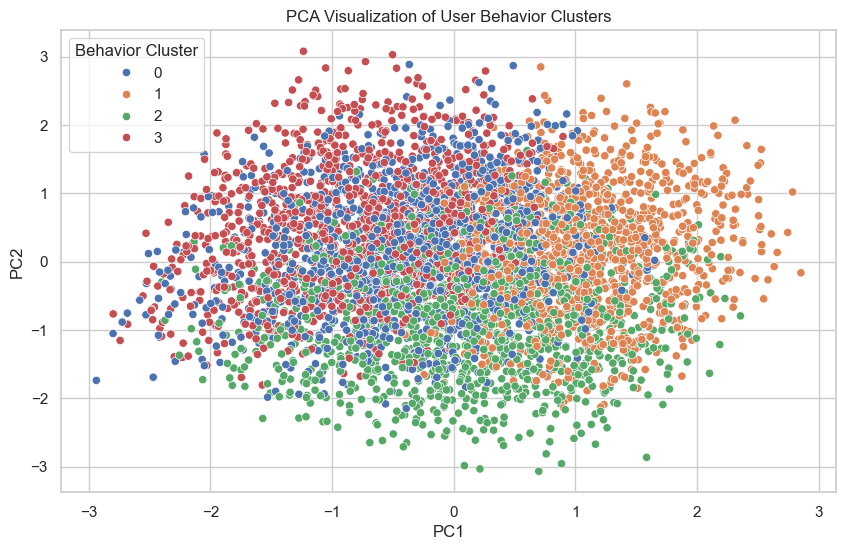

,Minutes Streamed Per Day,Number of Songs Liked,Discover Weekly Engagement (%),Repeat Song Rate (%)
Behavior Cluster,,,,
0,371.485459,286.290828,51.365541,63.704728
1,447.118410,273.546240,49.700424,30.463405
2,287.375000,218.262579,50.850393,25.269929
3,134.282114,235.404065,49.118732,48.079472


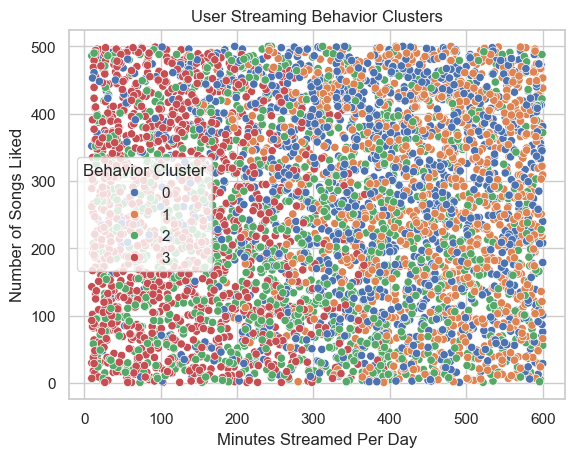

In [161]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("Global_Music_Streaming_Listener_Preferences (1).csv")

features = df.select_dtypes(include=[np.number])

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

kmeans = KMeans(n_clusters=4, random_state=42)
df["Behavior Cluster"] = kmeans.fit_predict(scaled_features)

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_features = pca.fit_transform(scaled_features)

df["PC1"] = pca_features[:, 0]
df["PC2"] = pca_features[:, 1]

plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x="PC1",
    y="PC2",
    hue="Behavior Cluster",
    palette="deep"
)
plt.title("PCA Visualization of User Behavior Clusters")
plt.show()

cluster_summary = df.groupby("Behavior Cluster")[[
    "Minutes Streamed Per Day",
    "Number of Songs Liked",
    "Discover Weekly Engagement (%)",
    "Repeat Song Rate (%)"
]].mean()

display(cluster_summary)

sns.scatterplot(
    data=df,
    x="Minutes Streamed Per Day",
    y="Number of Songs Liked",
    hue="Behavior Cluster",
    palette="deep"
)
plt.title("User Streaming Behavior Clusters")
plt.show()

PCA is applied to reduce the scaled engagement features into two principal components. This allows the discovered listener clusters to be visualized in two dimensions while preserving as much variance as possible.

K-Means clustering was selected to identify natural listener behavior groups using variables which indicate continuous engagement: Minutes Streamed Per Day, Number of Songs Liked, Discover Weekly Engagement (%), and Repeat Song Rate (%). These directly showcase and measure user listening intensity, interaction, and replay behavior.

A 4-cluster solution was chosen because it produces distinct and interpretable listener segments.

In [165]:
# based on feedback: df.groupby("Behavior Cluster")[[features]].mean()
print(cluster_summary)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance captured:", pca.explained_variance_ratio_.sum())



                  Minutes Streamed Per Day  Number of Songs Liked  \
Behavior Cluster                                                    
0                               371.485459             286.290828   
1                               447.118410             273.546240   
2                               287.375000             218.262579   
3                               134.282114             235.404065   

                  Discover Weekly Engagement (%)  Repeat Song Rate (%)  
Behavior Cluster                                                        
0                                      51.365541             63.704728  
1                                      49.700424             30.463405  
2                                      50.850393             25.269929  
3                                      49.118732             48.079472  
Explained variance ratio: [0.20860823 0.20484772]
Total variance captured: 0.41345594562518617


The first two principal components capture 41.35% of the total variance.

While this does not preserve the majority of the original variance, it is still useful for visualizing broad separation trends between listener clusters. The remaining variance suggests that there are other factors influencing user behavior which is beyond what can be fully represented in two components.

In [ ]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

df = pd.read_csv("Global_Music_Streaming_Listener_Preferences (1).csv")

# Remove USER ID
df = df.drop(columns=["User_ID"])

#Discretization
# Convert numerical columns into categories
df["Minutes Category"] = pd.qcut(
    df["Minutes Streamed Per Day"],
    q=4,
    labels=["Low","Medium","High","Very High"]
)

df["Songs Liked Category"] = pd.qcut(
    df["Number of Songs Liked"],
    q=4,
    labels=["Low","Medium","High","Very High"]
)

df["Repeat Rate Category"] = pd.qcut(
    df["Repeat Song Rate (%)"],
    q=4,
    labels=["Very Low","Low","Medium","High"]
)

df["Discover Weekly Category"] = pd.qcut(
    df["Discover Weekly Engagement (%)"],
    q=4,
    labels=["Very Low","Low","Medium","High"]
)

transactions = df[[
    "Country",
    "Top Genre",
    "Streaming Platform",
    "Minutes Category",
    "Discover Weekly Category",
    "Repeat Rate Category"
]]

# basket format
basket = pd.get_dummies(transactions)

# Find frequent itemsets
frequent_itemsets = apriori(basket, min_support=0.05, use_colnames=True)


> Association rules through Apriori are applied as the data mining technique.

> Looking at the results of these rules from a business perspective, what is suggested is that highly engaged listeners behave more like discovery-driven consumers than repeat-driven fans. This implies that recommendation algorithms should prioritize suggesting new music, personalized playlists, and similar genres to what is most frequently played for users with high 'like' activity but lower replay frequency. Contradictiry to this, users with high repeat rates may respond better to 'nostalgia playlists', artist-focused playlists, and favorite-track suggestion strategies.

In [ ]:
# Generate association rules
print("Association Rules:")
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=0.6)
rules = rules[rules["lift"] > 0.5]
# Show top rules

print(rules.sort_values("lift", ascending=False).head(10))

# Make rules readable
rules_readable = rules.copy()

rules_readable["Antecedent"] = rules_readable["antecedents"].apply(lambda x: ', '.join(list(x)))
rules_readable["Consequent"] = rules_readable["consequents"].apply(lambda x: ', '.join(list(x)))

rules_readable = rules_readable[["Antecedent","Consequent","support","confidence","lift"]]

# Sort by strongest rules
rules_readable = rules_readable.sort_values(by="lift", ascending=False)
print("")
print("Apriori:")
print(rules_readable.head(10))

>Minimum Support: 0.05 (5%) as the dataset has ~5000 rows, so this ensures that there a rule occurring in at least 250 users.
>Minimum Confidence: 0.6 (60%) as it ensures that the rule’s consequent occurs when the antecedent occurs, giving reliability.

>Frequent Item Sets Discovered:

| Feature | Label | Support |
| :--- | :--- | :--- |
| **Country** | USA | 0.45 |
| **Subscription Type** | Premium | 0.34 |
| **Streaming Platform** | Spotify | 0.31 |
| **Top Genre** | Pop | 0.29 |
| **Songs Liked** | Very High | 0.17 |
| **Repeat Rate** | Low | 0.13 |
| **Minutes Streamed** | Very High | 0.10 |



| Rule | Support | Confidence | Lift | Interpretation |
| :--- | :---: | :---: | :---: | :--- |
| **Songs Liked: Very High & Subscription: Premium** → Repeat Rate: Low | 0.05 | 0.38 | 1.12 | Premium users who like many songs usually repeat songs less. |
| **Repeat Rate: Low** → Songs Liked: Very High & Subscription: Premium | 0.05 | 0.15 | 1.12 | Users who repeat songs less are likely to own Premium. |
| **Minutes: Very High** → Country: UK | 0.05 | 0.11 | 1.11 | High streaming users are more likely to be in the UK. |
| **Country: UK** → Minutes: Very High | 0.05 | 0.50 | 1.11 | A slight tendency was observed between UK listeners and high streaming duration, but the lift value of 1.11 suggests this relationship is weak and only marginally above random co-occurrence.|
| **Streaming Platform: Spotify** → Discover Weekly: Low | 0.06 | 0.34 | 1.10 | Spotify users often have low engagement with Discover Weekly. |


>Interpretation:

>Behavioral patterns: High engagement users, who hold many liked songs or own premium, tend to not repeat songs. 

>Geography-platform interactions: Some countries stream more, and hold higher engagement with specfic platforms.

>It is surprising to see how certain countries, such as the UK, stream at a higher amount of minutes, but the most surprising being how those with a Premium subscription do not repeat songs, even though it is one of the highlighted marketing points for Premium subscriptions across platforms. However, as an actionable interpretation, understanding streaming patterns can help curate playlists to retain user interaction by focusing on less repeats and more on featuring songs based on their liked songs.

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Select features for clustering
X = df[[
    "Minutes Streamed Per Day",
    "Number of Songs Liked",
    "Discover Weekly Engagement (%)",
    "Repeat Song Rate (%)"
]]

# Scale for KMeans
scaler = StandardScaler()
scaled_X = scaler.fit_transform(X)

# Create behavior clusters
kmeans = KMeans(n_clusters=4, random_state=42)
df["Behavior Cluster"] = kmeans.fit_predict(scaled_X)

# Target variable for decision tree
y = df["Behavior Cluster"]

# Train decision tree
tree = DecisionTreeClassifier(max_depth=4, random_state=42)
tree.fit(X, y)

# Plot tree
plt.figure(figsize=(30,15), dpi=120)

plot_tree(
    tree,
    feature_names=X.columns,
    class_names=[str(c) for c in tree.classes_],
    filled=True,
    rounded=True,
    fontsize=10
)

plt.title("Decision Tree Explaining User Behavior Clusters", fontsize=16)
plt.show()

Decision Tree Description:
The given tree shows how different listening habits group users into behavior clusters, such as the ones described at the beginning of the section. It looks at factors such as how many minutes people stream per day, how many songs they like, how much they use Discover Weekly, and how often they repeat songs. The splits in the tree show which habits separate one group of users from another, and the leaves show the most common cluster for each group.

The cluster assignments discovered through K-Means are used as class labels. 
The decision tree serves as an interpretability tool that explains what listening behaviors distinguish the discovered user segments.

Measuring:
Minutes Streamed Per Day – daily listening time.
Number of Songs Liked – user engagement with tracks.
Discover Weekly Engagement (%) – interaction with personalized playlists.
Repeat Song Rate (%) – frequency of replaying songs.

# M2 Preliminary Findings with Interpretation

Connecting to Discover Questions:

My discovery questions were given the feedback of being weak, so my comparisons focus on new questions. For example, "What associations exist between countries and genre preferences?"
In comparison to this first discovery question, what stood out from the EDA and association rules is there there is an uneven distribution of genres across the listed countries. For example, Germany listens to the EDM genre the most at 71 listeners, being the only nation to hold more than 60 listeners within this data sheet. This suggests that there is a geographic trend within Germany which makes EDM much more popular within the country.

My second discovery question has been rephrased to include trends within listening platforms, questioning "How do platform choice and user engagement correlate?" By focusing on this, the data has shown Spotify → Low Discover Weekly engagement (support = 5.68%, confidence = 34.3%, lift = 1.10) suggests that Spotify users are less likely to interact with automated playlists compared. Similarly, Amazon Music → High Songs Liked & Low Repeat Rate” (support = 5.3%, confidence = 30.7%, lift = 1.10) shows that Amazon Music users tend to explore more songs without repeating them. This may hold implications over how different recommendation algorithms affect user engagement, or imply that there are platform-specfic behaviors that may contribute to different spikes.

My third discovery question, "Do certain genres have a skewed age distribution within their region?" more properly connect with my findings from the line chart. This data shows that, though certain genres tend to be more popular within certain age groups, the data can be skewed by popularity within different regions. For example ages 18-24 hold hip-hop as their top genre, but it could be skewed by South Korea, which has Hip-Hop as one of its top genres, with listeners mainly being young adults.

Limitations and Surprises:

Limitations often came by mistakes made in M1, for example, changing Discovery Questions to better interpret the data, and expanding the focus on simply age and region, to also look at engagement and behavioral trends within streaming platforms. 
For example, Germany listening to EDM the most is not surprising, but seeing the UK with the highest minutes of streaming is interesting, as there is not a clear showcase of what could be causing this. 
As a result, my plan for M3 to M4 is to build off of geographical rules to apply to behavioral patterns. For example, looking into South Korea's hip-hop trend by cross-referencing the outliers in my data with historical and cultural factors across these regions. 

# Geographical Context

In addressing listening trends which stood out in M2, I looked to existing research focusing on music scenes and industries within each country.

According to Brittanica, "Germany, in particular Berlin, was...an important locale in the development of electronic dance music", which quickly rose after the 1989 fall of the Berlin Wall. Taking in techno music, Berlin's growing club scene can be interpreted as a result of western music no longer being banned amongst the residents of East Germany and East Berlin.

As for South Korea's Hip-Hop trend, the Oxford Research Encyclopedia describes how idol-culture has maintained K-POP at a high stands amongst youth, but it's origins stem from Hip-Hop of the 90s. Influenced by western music, Hip-Hop laid the groundwork for the K-POP industry, and continues to interlap with much of its products, adding to the Hip-Hop listener count.

In [188]:
import pandas as pd
ct=pd.crosstab(df['Country'], df['Top Genre'])
styled_ct = ct.style.background_gradient(cmap='YlGnBu', axis=1, high=0.5)
styled_ct

Top Genre,Classical,Country,EDM,Hip-Hop,Jazz,Metal,Pop,R&B,Reggae,Rock
Country,,,,,,,,,,
Australia,47,49,53,55,60,43,61,48,55,55
Brazil,59,53,48,39,45,44,56,57,46,61
Canada,37,51,59,51,57,38,56,54,55,49
France,42,47,50,52,59,51,35,51,55,51
Germany,45,45,71,44,44,56,37,50,37,42
India,55,49,42,54,52,45,40,45,62,46
Japan,45,55,48,48,57,51,55,41,49,42
South Korea,48,47,56,61,51,52,34,52,51,64
UK,49,42,42,47,56,58,45,59,63,55


# M3 Findings with Interpretation

While M2 identified geographic genre trends, platform-specific engagement differences, and age-based listening skews, M3 builds off of these observations using clustering, PCA, association rules, and decision tree classification to confirm whether these patterns show meaningful listener patterns and platform behaviors.

Discovery Question 1: 

So far, what's been learned is that the analysis continues to show that genre popularity is not evenly distributed across countries. Germany remains the clearest example, with EDM having the strongest concentration at 71 listeners, while South Korea continues to show unusually high Hip-Hop and Rock counts. These patterns suggest that listener preference is influenced by geographic concentration rather than a random spread.

As for techniques, data has mainly been processed and visualized using:

Grouped frequency tables,
boxplots for outlier detection,
bar charts by country and genre,
Apriori association rules
K-Means clustering for broader behavioral grouping

The results have been that specific countries appear to amplify certain genres, especially Germany with EDM and South Korea with Hip-Hop. M3 strengthens this by showing that these country-level skews likely connect to broader listener personas discovered in clustering. For example, countries with stronger exploration behavior may produce higher counts in fast-changing genres like EDM and Hip-Hop.

What remains unclear is further information on why these countries show stronger concentration. Where the dataset lacks information, outside sources have been used to back up cultural and historical factors. As for external music market factors, sources with greater information should be found to elaborate on the visual proof of these trends.

Discover Question 2: How do platform choice and user engagement correlate?

So far, what's been learned is that platform choice appears closely tied to how users engage with music. Earlier findings showed Spotify users tending toward lower Discover Weekly interaction, while Premium users and users with many liked songs often had lower repeat behavior. M3 clustering strengthens this by identifying Heavy Explorers, users with the highest streaming minutes but lower replay habits.

As for techniques, data has mainly been processed and visualized using:

association rules, 
K-Means clustering, 
PCA visualization, 
decision tree classification, and 
cluster summary statistics

The current results show that platform behavior aligns with listening style. Users on some platforms appear more discovery-driven, spending more time streaming and liking songs while not replaying as often. This could imply that platform ecosystems may encourage exploration rather than repeats.

What remains unclear is whether or not this behavior is caused by the platform itself or by the type of users attracted to that platform. Future research could benefit from using an application's basic suggestion algorithm, dissecting it to understand where problems may occur.

Question 3: Do certain genres have a skewed age distribution within their region?

The line chart and age-group visualizations show that genres such as EDM, Hip-Hop, and Rock cluster around younger age groups, while Country and Jazz appear stronger in older groups. M3 expands this by showing that these age skews may reflect deeper behavioral differences in exploration and repeat listening patterns. Furthermore, the external academic article by Crystal S Anderson presented in section 5 may reflect why this cluster exists. For example, K-POP, often falling within the Hip-Hop genre, having a strong fanbase among South Korea's youth. 

Which techniques addressed this question?

This question was supported through techniques such as:

age-binned line charts, 
countplots by age, 
PCA visualization, 
K-Means clustering, and 
decision tree splits using engagement metrics

As of now, there are results which show some genres skew toward younger or older listener groups, but the skew is better explained through engagement behavior than just age. Younger listeners may align more with discovery-heavy clusters, while older groups may fit more selective, nostalgic, or replay-based segments. There is also the geographical context, such as Berlin's club-culture and its growth since the fall of the Berlin Wall.

What is still unclear is how much of the age effect is actually caused by regional genre popularity versus age itself. Since age and country were not jointly modeled in clustering, the interaction between these two factors needs deeper analysis.

The most important progression from M2 to M3 is the shift from surface-level frequency observations to model-supported listener segmentation. M2 identified what trends existed, while M3 better explains why those trends occur by uncovering four cluster interpretations for users, including heavy repeat listeners, explorers, casual selective users, and light Replay Users. This transition adds depth because the findings now have repeatable, labeled behaviors to represent and apply to, rather than simple chart-level observations.